<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\tangb\AppData\Local\Temp\ipykernel_39520\3450972568.py:11: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')


shape: (90189, 5)
   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True
<class 'pandas.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   userid          90189 non-null  int64
 1   version         90189 non-null  str  
 2   sum_gamerounds  90189 non-null  int64
 3   retention_1     90189 non-null  bool 
 4   retention_7     90189 non-null  bool 
dtypes: bool(2), int64(2), str(1)
memory usage: 2.2 MB
None
             userid  sum_gamerounds
count  9.018900e+04    90189.000000
mean   4.998412e+06       51.872457
std    2.883286e+06      195.050858
min    1.16000

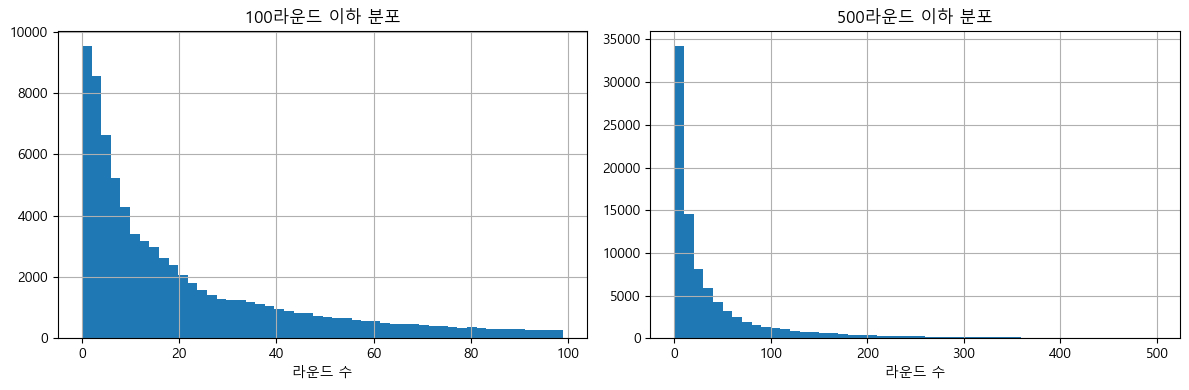

0라운드 유저 수: 3994
500라운드 이상 유저 수: 860
user_type
미들      38584
헤비      26888
라이트     20723
즉시이탈     3994
Name: count, dtype: int64
user_type
미들      42.8
헤비      29.8
라이트     23.0
즉시이탈     4.4
Name: proportion, dtype: float64


In [1]:
# 01_EDA.ipynb

# =====================
# 1. 라이브러리 로드
# =====================
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

df = pd.read_csv('..\data\cookie_cats.csv\cookie_cats.csv')

# =====================
# 2. 기본 데이터 확인
# =====================
print("shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())

# =====================
# 3. 게임 라운드 분포
# =====================
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[df['sum_gamerounds']<100]['sum_gamerounds'].hist(bins=50)
plt.title('100라운드 이하 분포')
plt.xlabel('라운드 수')

plt.subplot(1, 2, 2)
df[df['sum_gamerounds'] < 500]['sum_gamerounds'].hist(bins=50)
plt.title('500라운드 이하 분포')
plt.xlabel('라운드 수')

plt.tight_layout()
plt.savefig('../images/round_distribution.png')
plt.show()

# =====================
# 4. 이상치 확인
# =====================
print("0라운드 유저 수:", (df['sum_gamerounds'] == 0).sum())
print("500라운드 이상 유저 수:", (df['sum_gamerounds'] >= 500).sum())

# =====================
# 5. 유저 세그먼트 생성
# =====================
def categorize_user(rounds):
    if rounds == 0:
        return '즉시이탈'
    elif rounds <= 5:
        return '라이트'
    elif rounds <= 40:
        return '미들'
    else:
        return '헤비'

df['user_type'] = df['sum_gamerounds'].apply(categorize_user)

print(df['user_type'].value_counts())
print(df['user_type'].value_counts(normalize=True).round(3) * 100)